/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.




Model Comparison on Test Set:
--------------------------------------------------
Additive NN:
  MSE: 3016.24
  R2:  0.431
Random Forest:
  MSE: 2952.01
  R2:  0.443
Linear Regression:
  MSE: 2900.19
  R2:  0.453
Standard NN:
  MSE: 2894.86
  R2:  0.454
--------------------------------------------------


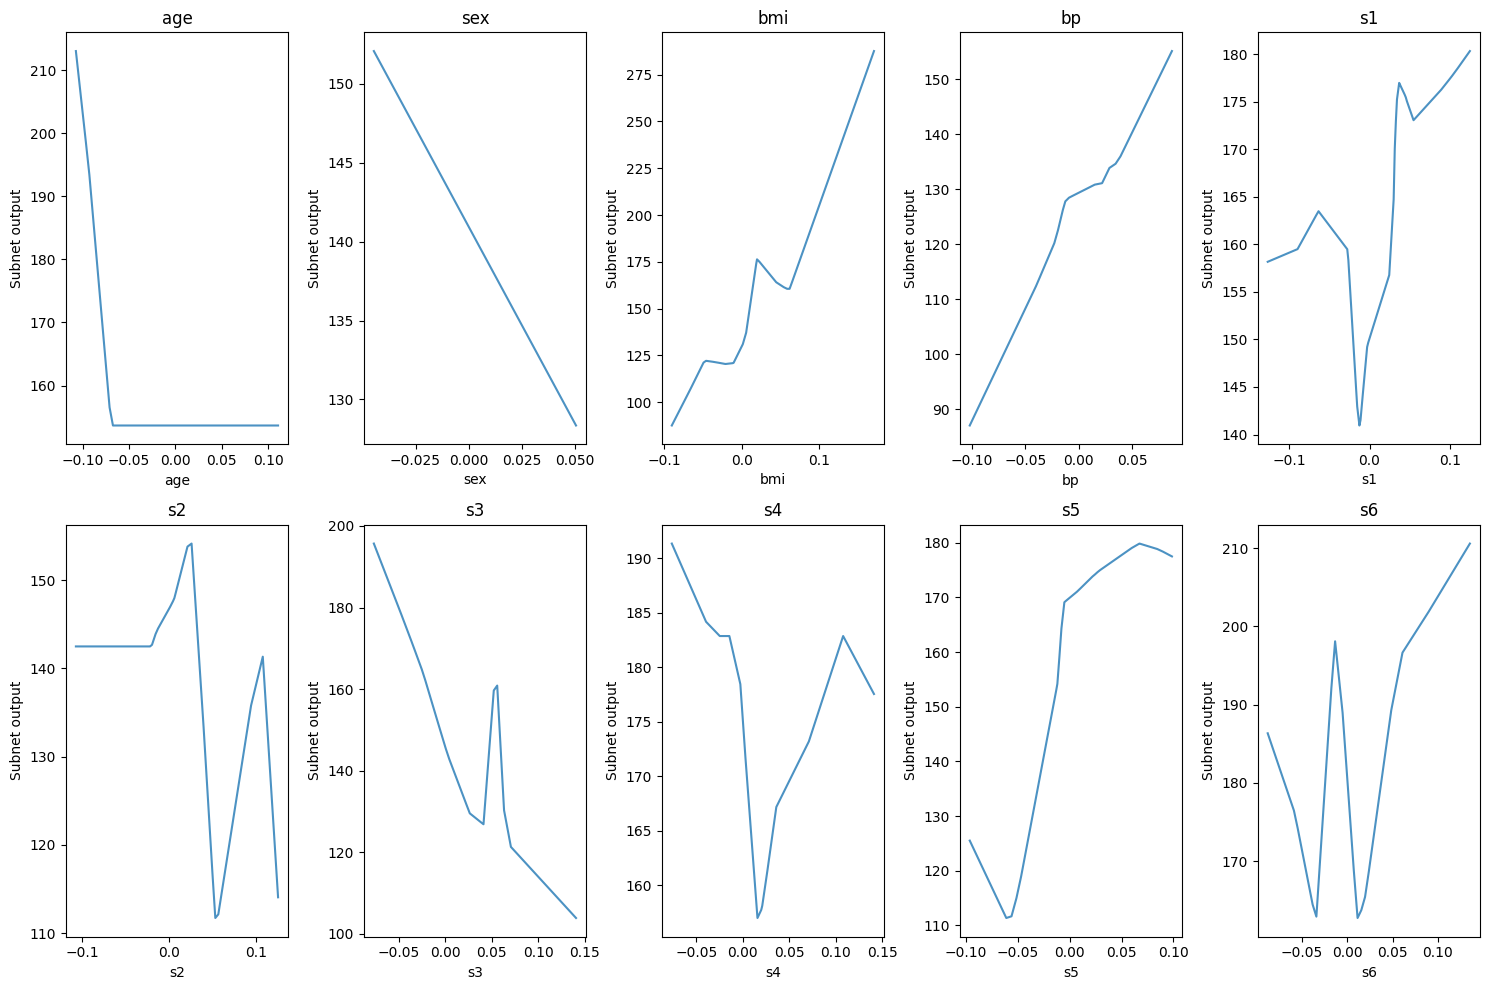

In [8]:
"""
Additive Neural Network Implementation
A neural network where each input feature has its own subnet and outputs are summed.
"""

import numpy as np
import torch
import torch.nn as nn
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

class SubNet(nn.Module):
    def __init__(self, hidden_sizes=[16, 8]):
        super().__init__()
        layers = []
        prev_size = 1  # Input size is always 1 for each subnet

        for size in hidden_sizes:
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.ReLU())
            prev_size = size

        layers.append(nn.Linear(prev_size, 1))  # Output size is always 1
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.unsqueeze(1))

class AdditiveNN(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_sizes=[16, 8], lr=0.01, epochs=100, batch_size=32):
        self.hidden_sizes = hidden_sizes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.subnets = None
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

    def fit(self, X, y):
        # Scale data
        X_scaled = self.scaler_x.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

        # Initialize subnets
        self.subnets = nn.ModuleList([SubNet(self.hidden_sizes) for _ in range(X.shape[1])])
        optimizer = torch.optim.Adam(self.subnets.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        # Convert to torch
        X_torch = torch.FloatTensor(X_scaled)
        y_torch = torch.FloatTensor(y_scaled)

        # Training
        for epoch in range(self.epochs):
            for i in range(0, len(X_torch), self.batch_size):
                batch_X = X_torch[i:i+self.batch_size]
                batch_y = y_torch[i:i+self.batch_size]

                optimizer.zero_grad()

                # Sum outputs from all subnets
                outputs = torch.zeros(len(batch_X))
                for j, subnet in enumerate(self.subnets):
                    outputs += subnet(batch_X[:, j]).squeeze()

                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        return self

    def predict(self, X):
        X_scaled = self.scaler_x.transform(X)
        X_torch = torch.FloatTensor(X_scaled)

        with torch.no_grad():
            outputs = torch.zeros(len(X_torch))
            for j, subnet in enumerate(self.subnets):
                outputs += subnet(X_torch[:, j]).squeeze()

        # Inverse transform the predictions
        return self.scaler_y.inverse_transform(outputs.numpy().reshape(-1, 1)).ravel()

    def get_subnet_prediction(self, i, X):
        """Get prediction from i-th subnet"""
        X_scaled = self.scaler_x.transform(X)
        X_torch = torch.FloatTensor(X_scaled)

        with torch.no_grad():
            output = self.subnets[i](X_torch[:, i]).squeeze()

        return self.scaler_y.inverse_transform(output.numpy().reshape(-1, 1)).ravel()

# Load and prepare data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train models
models = {
    'Additive NN': AdditiveNN(hidden_sizes=[16, 8], epochs=100),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Standard NN': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# Train models and collect results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

# Print comparison results
print("\nModel Comparison on Test Set:")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  MSE: {metrics['MSE']:.2f}")
    print(f"  R2:  {metrics['R2']:.3f}")
print("-" * 50)

# Plot subnet responses
additive_nn = models['Additive NN']
plt.figure(figsize=(15, 10))
for i, feature_name in enumerate(feature_names):
    plt.subplot(2, 5, i+1)

    # Sort points for clean visualization
    sort_idx = np.argsort(X_test[:, i])
    X_sorted = X_test[sort_idx, i]

    # Get subnet prediction
    y_subnet = additive_nn.get_subnet_prediction(i, X_test)
    y_subnet_sorted = y_subnet[sort_idx]

    plt.plot(X_sorted, y_subnet_sorted, alpha=0.8, label='Subnet response')
    plt.title(feature_name)
    plt.xlabel(feature_name)
    plt.ylabel('Subnet output')

plt.tight_layout()
plt.show()

In [9]:
!pip -q install interpret

In [10]:
"""
Model comparison using Explainable Boosting Machine (EBM) from InterpretML
"""

import numpy as np
from interpret import show
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load and prepare data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'EBM': ExplainableBoostingRegressor(
        random_state=42,
        feature_names=feature_names,  # Pass feature names to EBM
    ),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)
}

# Train models and collect results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

# Print comparison results
print("\nModel Comparison on Test Set:")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  MSE: {metrics['MSE']:.2f}")
    print(f"  R2:  {metrics['R2']:.3f}")
print("-" * 50)

# Get EBM explanations and show them
ebm = models['EBM']
ebm_global = ebm.explain_global()
show(ebm_global)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.




Model Comparison on Test Set:
--------------------------------------------------
EBM:
  MSE: 2775.02
  R2:  0.476
Random Forest:
  MSE: 2952.01
  R2:  0.443
Linear Regression:
  MSE: 2900.19
  R2:  0.453
Neural Network:
  MSE: 2828.07
  R2:  0.466
--------------------------------------------------
